# 07 微积分和梯度直觉

本节学习导数、偏导数、梯度、链式法则，并用一个简单函数理解：**梯度告诉参数往哪里改**。

## 1. 最小概念

- 导数：描述一个函数在某一点的变化速度，也就是曲线在这一点的斜率。
- 偏导数：当函数有多个变量时，只看其中一个变量变化，其他变量先固定。
- 梯度：由所有偏导数组成的向量，表示函数上升最快的方向。
- 链式法则：复合函数求导时，把外层变化率和内层变化率相乘。

训练模型时，我们通常想让损失函数变小。梯度指向损失上升最快的方向，所以参数更新时要往梯度的反方向走：

`参数 = 参数 - 学习率 * 梯度`

In [1]:
import torch
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4)


def loss_fn(w):
    return (w - 3) ** 2

## 2. 画一条简单函数曲线

这里画 `loss(w) = (w - 3)^2`。它的最低点在 `w = 3`，也就是损失最小的位置。

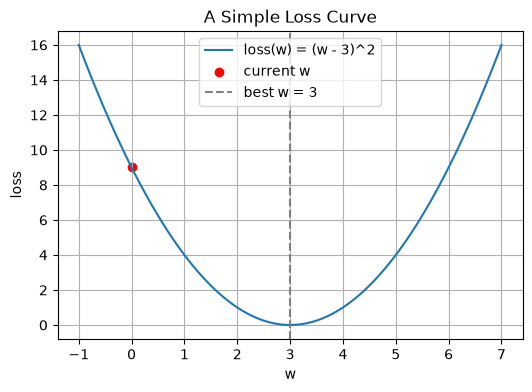

w_values shape: (100,)
loss_values shape: (100,)


In [2]:
w_values = torch.linspace(-1, 7, steps=100)
loss_values = loss_fn(w_values)

current_w = torch.tensor(0.0)
current_loss = loss_fn(current_w)

plt.figure(figsize=(6, 4))
plt.plot(w_values, loss_values, label="loss(w) = (w - 3)^2")
plt.scatter([current_w.item()], [current_loss.item()], color="red", label="current w")
plt.axvline(3, color="gray", linestyle="--", label="best w = 3")
plt.xlabel("w")
plt.ylabel("loss")
plt.title("A Simple Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

print("w_values shape:", tuple(w_values.shape))
print("loss_values shape:", tuple(loss_values.shape))

## 3. 梯度告诉参数往哪里改

假设当前参数 `w = 0`，损失是 `(0 - 3)^2 = 9`。

这个函数的导数是 `2 * (w - 3)`。当 `w = 0` 时，梯度是 `-6`。

- 梯度为负：函数往右走会上升得没那么快，往梯度反方向更新会让 `w` 变大
- 梯度为正：往梯度反方向更新会让 `w` 变小
- 梯度接近 0：说明已经接近最低点

所以训练模型时常用：`w = w - lr * gradient`。

In [ ]:
w = torch.tensor(0.0, requires_grad=True)
loss = loss_fn(w)
loss.backward()

lr = 0.1
with torch.no_grad():
    new_w = w - lr * w.grad
    new_loss = loss_fn(new_w)

print("当前参数 w:", w.item())
print("当前损失 loss:", loss.item())
print("梯度 dloss/dw:", w.grad.item())
print("更新公式: new_w = w - lr * grad")
print("更新后参数 new_w:", new_w.item())
print("更新后损失 new_loss:", new_loss.item())

## 4. 偏导数和梯度

当函数有多个参数时，每个参数都有自己的偏导数。所有偏导数组合起来，就是梯度。

例如：`z = x^2 + 3y^2`。

- 对 `x` 的偏导数是 `2x`
- 对 `y` 的偏导数是 `6y`
- 梯度是 `[2x, 6y]`

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

z = x ** 2 + 3 * y ** 2
z.backward()

gradient = torch.tensor([x.grad.item(), y.grad.item()])

print("z = x^2 + 3y^2")
print("x:", x.item(), "y:", y.item())
print("dz/dx:", x.grad.item())
print("dz/dy:", y.grad.item())
print("梯度 [dz/dx, dz/dy]:", gradient)
print("gradient shape:", tuple(gradient.shape))

## 5. 链式法则

链式法则用来处理一层套一层的函数。

例如：

`u = x^2`

`v = u + 1`

`loss = v^2`

`x` 影响 `u`，`u` 影响 `v`，`v` 影响 `loss`。反向传播就是沿着这条链，把梯度一层一层传回去。

In [ ]:
x = torch.tensor(2.0, requires_grad=True)

u = x ** 2
v = u + 1
loss = v ** 2
loss.backward()

manual_grad = 2 * v.detach() * 2 * x.detach()

print("u = x^2:", u.item())
print("v = u + 1:", v.item())
print("loss = v^2:", loss.item())
print("PyTorch 算出的 dloss/dx:", x.grad.item())
print("按链式法则手算 dloss/dx:", manual_grad.item())

## 小结

- 导数：单变量函数某一点的变化速度。
- 偏导数：多变量函数中，一个变量的变化影响。
- 梯度：所有偏导数组成的向量，指向函数上升最快的方向。
- 链式法则：复合函数求导时，梯度沿计算链逐层相乘。

训练模型的核心直觉：**梯度告诉损失往哪里变大，所以参数要往梯度的反方向改，损失才会变小。**